# Расположение 368 Xela-сенсоров на руке

Цель ноутбука: связать flattened-порядок сенсоров `0..367` с физическими частями Allegro hand и показать 3D-расположение сенсоров в нескольких моментах времени.

Источники контекста: на странице статьи Sparsh-skin вход модели описан как история тактильных наблюдений вместе с 3D позициями сенсоров; dataset card Hugging Face описывает структуру последовательности как `allegro`, `xela` и `urdf`.

- Article: https://akashsharma02.github.io/sparsh-skin-ssl/
- Dataset: https://huggingface.co/datasets/facebook/sparsh-skin-dataset


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from omegaconf import OmegaConf

repo_root = Path.cwd()
if repo_root.name == "graph_visualizations":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from tactile_ssl.data.xela_tactile import XelaSSLDataset
from tactile_ssl.data.xela.utils import XELA_FLATTEN_ORDER
from tactile_ssl.graph.utils import (
    HAND_PART_LABELS_RU,
    HAND_PART_TO_SENSORS,
    SENSOR_TO_HAND_PART,
    iter_sensor_ranges,
    validate_against_xela_flatten_order,
)
from tactile_ssl.graph.vis_utils import plot_sensor_positions, plot_sensor_positions_2d

validate_against_xela_flatten_order(XELA_FLATTEN_ORDER)


## Словарь: часть руки -> номера сенсоров

Порядок сенсоров соответствует `XELA_FLATTEN_ORDER`, то есть тому же flattened-порядку, в котором `XelaSSLDataset` возвращает `sensor` и `sensor_poses`.

In [2]:
for sensor_range in iter_sensor_ranges():
    label = HAND_PART_LABELS_RU[sensor_range.hand_part]
    print(
        f"{sensor_range.start:3d}..{sensor_range.end - 1:3d} | "
        f"{sensor_range.link_name:28s} | {label} ({sensor_range.hand_part})"
    )

print("\nГруппы сенсоров по частям руки:\n")
for hand_part, sensor_ids in HAND_PART_TO_SENSORS.items():
    label = HAND_PART_LABELS_RU[hand_part]
    print(f"{label} ({hand_part}), n={len(sensor_ids)}:")
    print(sensor_ids)


  0.. 29 | 3aftc_palm_link              | большой палец (thumb)
 30.. 45 | link_15_4x4_palm_link        | большой палец (thumb)
 46.. 61 | link_14_4x4_palm_link        | большой палец (thumb)
 62.. 91 | 0aftc_palm_link              | указательный палец (index_finger)
 92..107 | link_2_4x4_palm_link         | указательный палец (index_finger)
108..123 | link_1A_4x4_palm_link        | указательный палец (index_finger)
124..139 | link_1B_4x4_palm_link        | указательный палец (index_finger)
140..169 | 1aftc_palm_link              | средний палец (middle_finger)
170..185 | link_6_4x4_palm_link         | средний палец (middle_finger)
186..201 | link_5A_4x4_palm_link        | средний палец (middle_finger)
202..217 | link_5B_4x4_palm_link        | средний палец (middle_finger)
218..247 | 2aftc_palm_link              | безымянный палец (ring_finger)
248..263 | link_10_4x4_palm_link        | безымянный палец (ring_finger)
264..279 | link_9A_4x4_palm_link        | безымянный палец (ring_finge

## Загрузка одной последовательности

Если рядом с репозиторием заполнена папка `facebook--sparsh-skin-dataset`, она используется первой. Иначе путь берется из `config/paths/default.yaml`. При необходимости задайте `DATA_ROOT_OVERRIDE` вручную. Ожидается корень датасета, внутри которого лежит `xela/pretraining/extracted`.

In [3]:
paths_cfg = OmegaConf.load(repo_root / "config" / "paths" / "default.yaml")
data_cfg = OmegaConf.load(repo_root / "config" / "data" / "xela.yaml")

DATA_ROOT_OVERRIDE = None  # например: "/path/to/sparsh-skin-dataset"
LOCAL_DATASET_CANDIDATE = repo_root / "facebook--sparsh-skin-dataset"
SEQUENCE_NAME = "drill"
SEQUENCE_ID = 0

if DATA_ROOT_OVERRIDE is not None:
    data_root = Path(DATA_ROOT_OVERRIDE).expanduser()
elif (LOCAL_DATASET_CANDIDATE / "xela" / "pretraining" / "extracted").exists():
    data_root = LOCAL_DATASET_CANDIDATE
else:
    data_root = Path(paths_cfg.data_root).expanduser()

extracted_root = data_root / "xela" / "pretraining" / "extracted"
sequence_path = extracted_root / SEQUENCE_NAME / str(SEQUENCE_ID)
baseline_signal_path = extracted_root / "baseline" / "xela" / "data.pkl"
urdf_path = extracted_root / "urdf" / "ahrcpcpn.urdf"

missing = [path for path in (sequence_path, baseline_signal_path, urdf_path) if not path.exists()]
if missing:
    missing_lines = "\n".join(f"- {path}" for path in missing)
    raise FileNotFoundError(
        "Не найдены файлы датасета для визуализации. "
        "Переопределите DATA_ROOT_OVERRIDE в этой ячейке на локальный корень sparsh-skin-dataset.\n"
        f"Проверенные пути:\n{missing_lines}"
    )

dataset_config = OmegaConf.create(
    {
        "window_time": data_cfg.window_time,
        "window_overlap": data_cfg.window_overlap,
        "interpolating_freq": data_cfg.interpolating_freq,
        "subtract_baseline": True,
        "smooth_data": False,
        "bias_noise_std": 0.0,
        "bias_range": 0.0,
        "cache": {"enabled": False, "root": str(repo_root / ".cache" / "xela_artifacts")},
        "preprocessing": data_cfg.preprocessing,
        "features": {"use_spatial_coords": False},
    }
)

dataset = XelaSSLDataset(
    config=dataset_config,
    data_path=str(sequence_path),
    xela_urdf_path=str(urdf_path),
    baseline_signal_path=str(baseline_signal_path),
    load_images=False,
)

print(f"data_root: {data_root}")
print(f"sequence_path: {sequence_path}")
print(f"windows: {len(dataset)}")
print(f"frames per window: {dataset.num_frames_per_window}")


data_root: /workspace-SR004.nfs2/kovtun/tactile/sparsh-skin-dataset
sequence_path: /workspace-SR004.nfs2/kovtun/tactile/sparsh-skin-dataset/xela/pretraining/extracted/drill/0
windows: 1187
frames per window: 10


## Расположение сенсоров в `t=0`, середине окна и конце окна

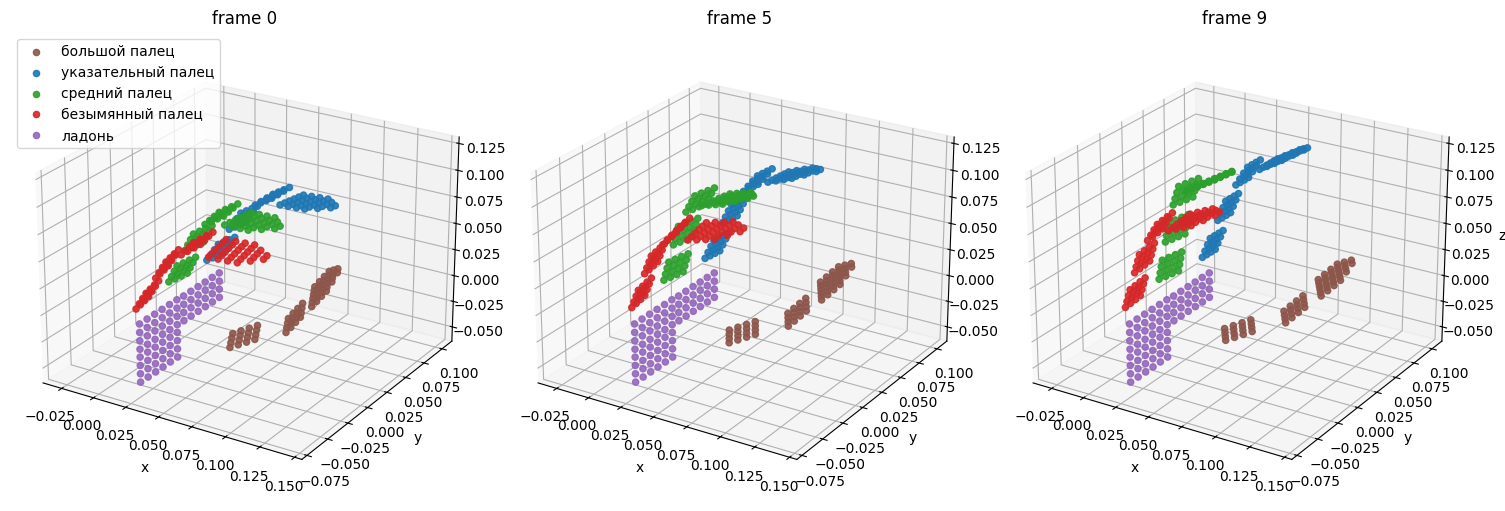

In [4]:
WINDOW_ID = 0
sample = dataset[WINDOW_ID]
sensor_poses = sample["sensor_poses"][:, :, :3]

frame_indices = (0, sensor_poses.shape[0] // 2, sensor_poses.shape[0] - 1)
fig = plot_sensor_positions(
    sensor_poses,
    frame_indices=frame_indices,
    sensor_to_part=SENSOR_TO_HAND_PART,
    show_legend=True,
    point_size=20,
)
plt.show()


## Номера сенсоров на их 3D-позициях

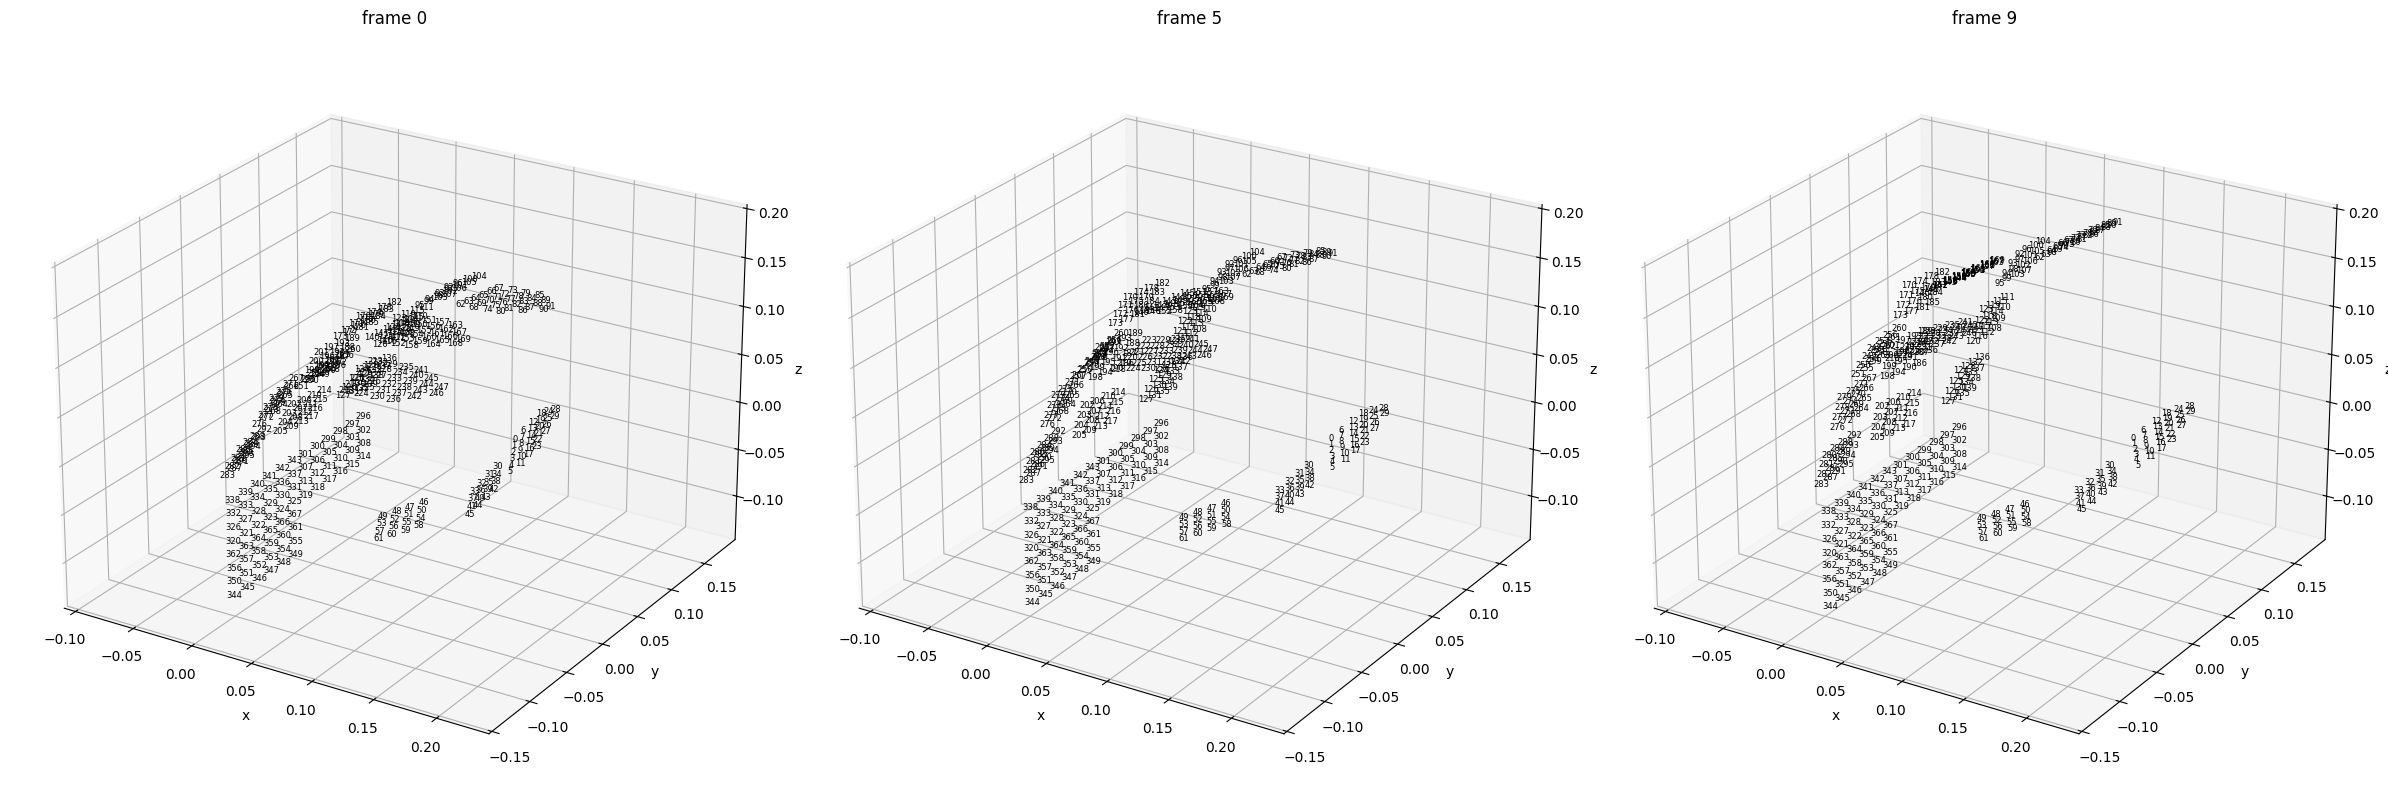

In [5]:
fig = plot_sensor_positions(
    sensor_poses,
    frame_indices=frame_indices,
    sensor_to_part=SENSOR_TO_HAND_PART,
    show_sensor_ids=True,
    show_points=False,
    show_legend=False,
    sensor_id_position_scale=1.8,
    figsize=(8 * len(frame_indices), 8),
)
plt.show()


## Номера сенсоров в 2D PCA-проекции

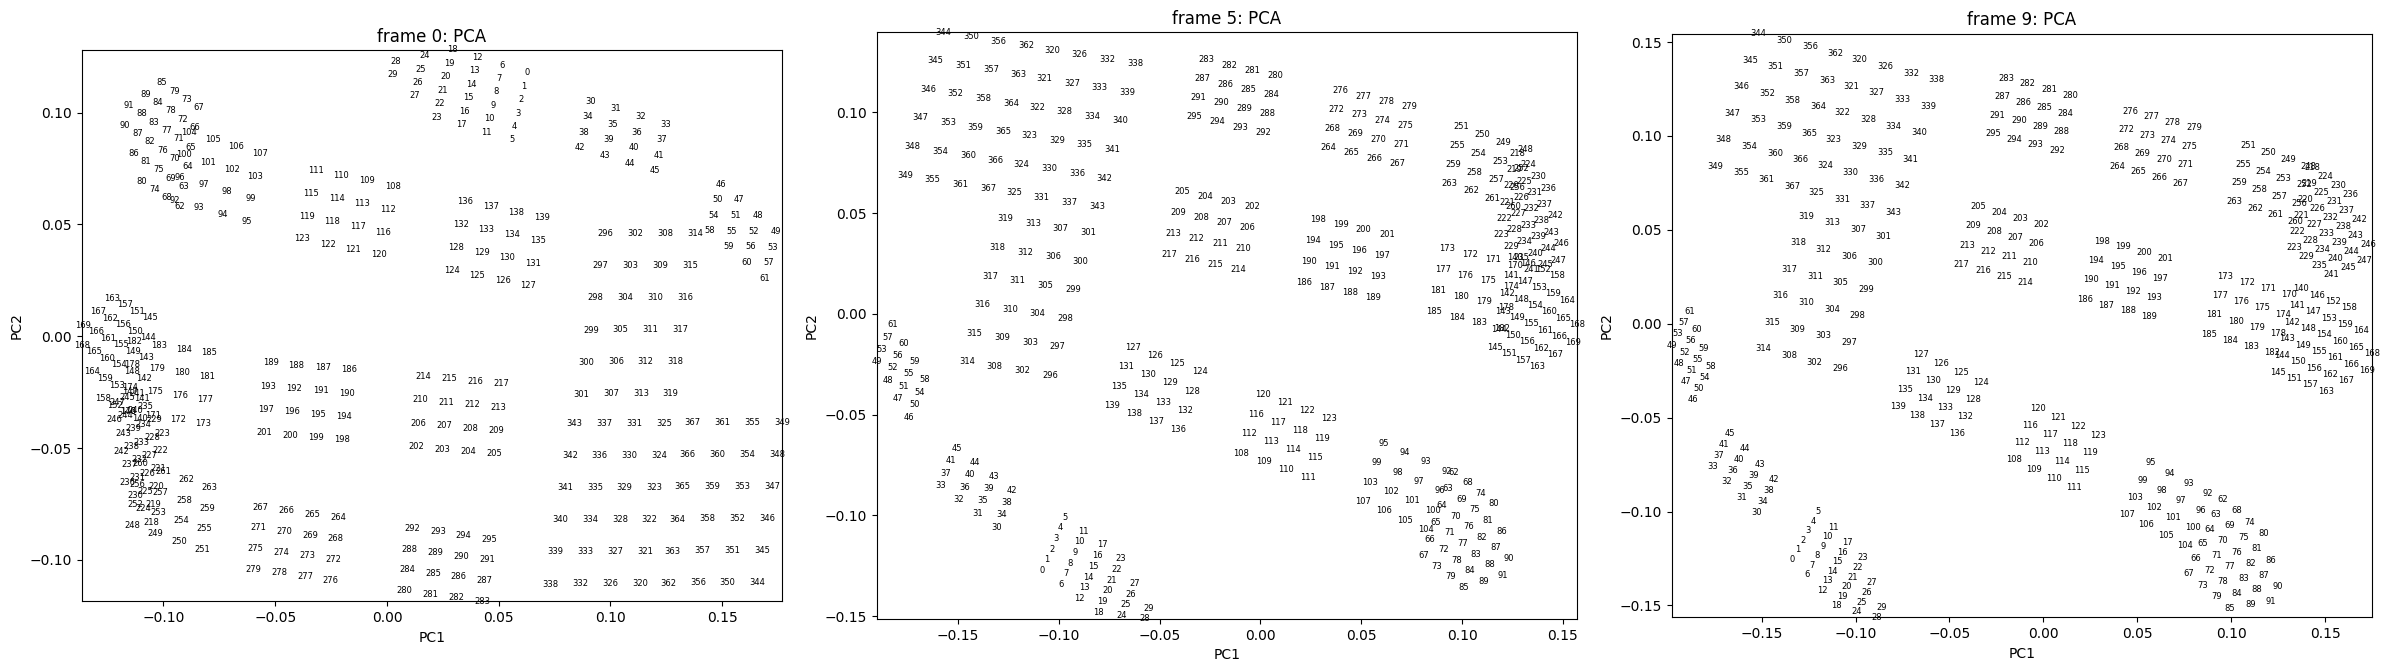

In [6]:
fig = plot_sensor_positions_2d(
    sensor_poses,
    frame_indices=frame_indices,
    sensor_to_part=SENSOR_TO_HAND_PART,
    show_sensor_ids=True,
    show_points=False,
    show_legend=False,
    sensor_id_position_scale=1.8,
    figsize=(8 * len(frame_indices), 8),
)
plt.show()


## Несколько окон подряд

Эта ячейка показывает первый кадр из нескольких окон, чтобы увидеть, как 3D-позиции сенсоров меняются вместе с суставами Allegro hand.

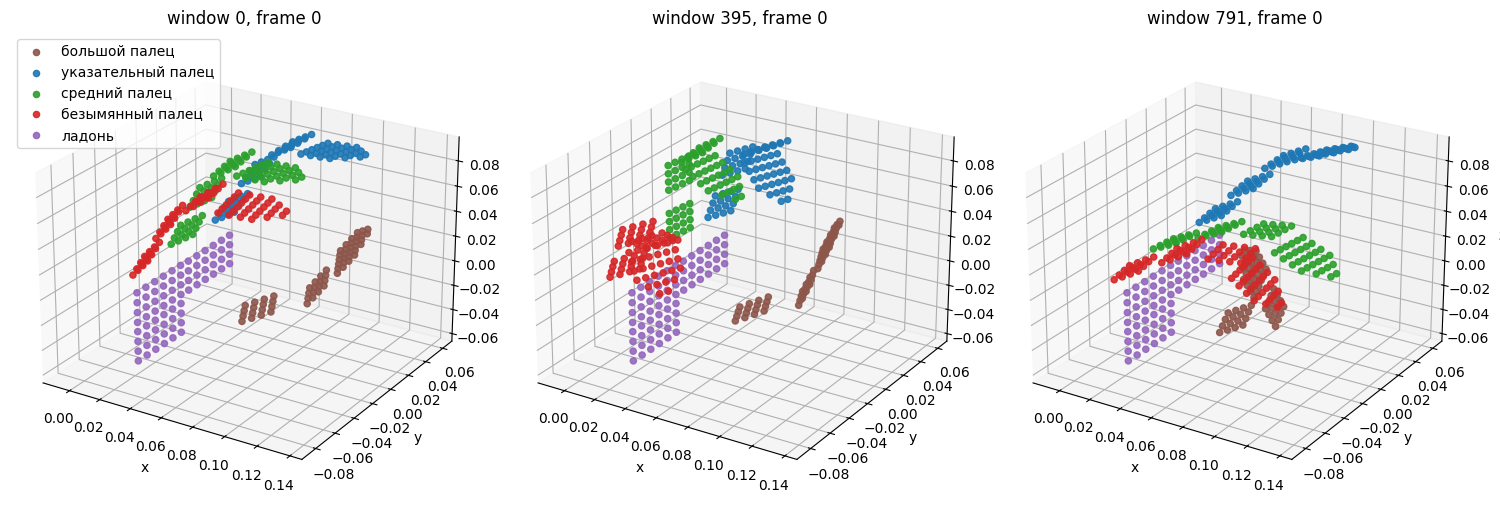

In [7]:
window_ids = [idx for idx in (0, len(dataset) // 3, 2 * len(dataset) // 3) if idx < len(dataset)]
window_first_frames = []
for window_id in window_ids:
    window_first_frames.append(dataset[window_id]["sensor_poses"][0, :, :3].detach().cpu().numpy())

fig = plot_sensor_positions(
    window_first_frames,
    frame_indices=range(len(window_first_frames)),
    sensor_to_part=SENSOR_TO_HAND_PART,
    show_legend=True,
    point_size=20,
)
for ax, window_id in zip(fig.axes, window_ids):
    ax.set_title(f"window {window_id}, frame 0")
plt.show()
